<a href="https://colab.research.google.com/github/raniaxshehata/LeistungsanalyseApp/blob/Edanur/SystemsBiology_Fall2025_LearnHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports numpy and scipy.integrate.odeint: These libraries are used for numerical operations and solving ODEs, respectively. matplotlib.pyplot is imported for plotting the results.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

The `hill_act` and `hill_rep` functions describe how the activity of a gene or protein is regulated by the concentration of another molecule (x).

*   **K (dissociation constant / threshold)**: Represents the concentration of x at which the function's output is half of its maximum value. A smaller K means a higher sensitivity to x.
*   **n (Hill coefficient / cooperativity)**: Indicates the steepness of the curve, reflecting the cooperativity of the interaction. A higher n implies a more switch-like (sigmoidal) response, meaning a small change in x around K leads to a large change in output.

In [ ]:
def hill_act(x, K, n):
    return (x**n)/((K**n)+(x**n))

def hill_rep(x, K, n):
    return (K**n)/((K**n)+(x**n))



**Hill functions**

visualizing how the parameters K (dissociation constant) and n (Hill coefficient) influence the shape of the Hill activation and repression functions.

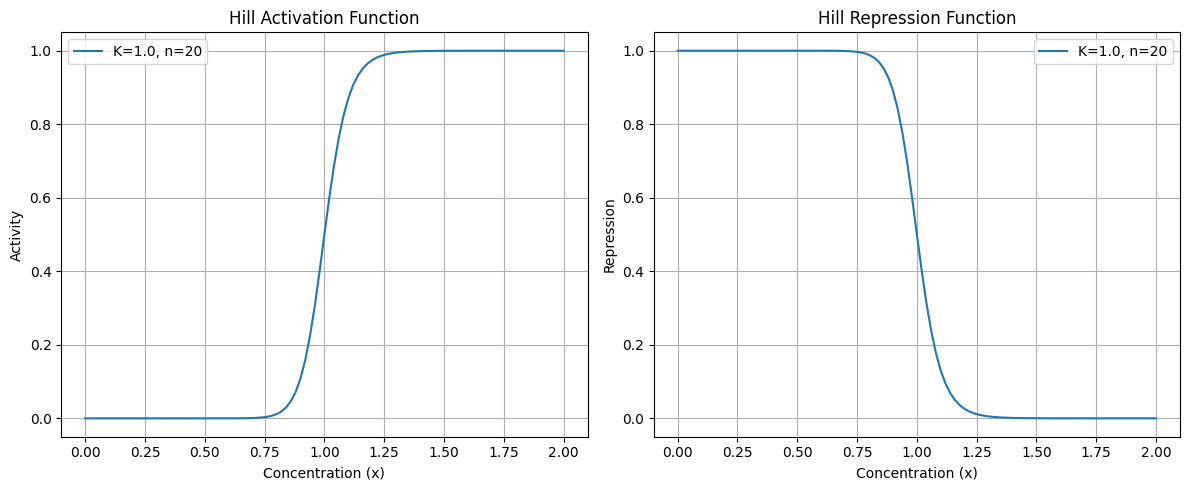

In [ ]:
# Generate a range of concentrations (x values)
x_vals = np.linspace(0, 2, 101)
hill_activity = hill_act(x_vals, K=1.0, n=20)
hill_repression = hill_rep(x_vals, K=1.0, n=20)

# Plot Hill Activation for K and n values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Hill Activation Function')
plt.plot(x_vals, hill_activity, label='K=1.0, n=20')
plt.xlabel('Concentration (x)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Hill Repression Function')
plt.plot(x_vals, hill_repression, label='K=1.0, n=20')
plt.xlabel('Concentration (x)')
plt.ylabel('Repression')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

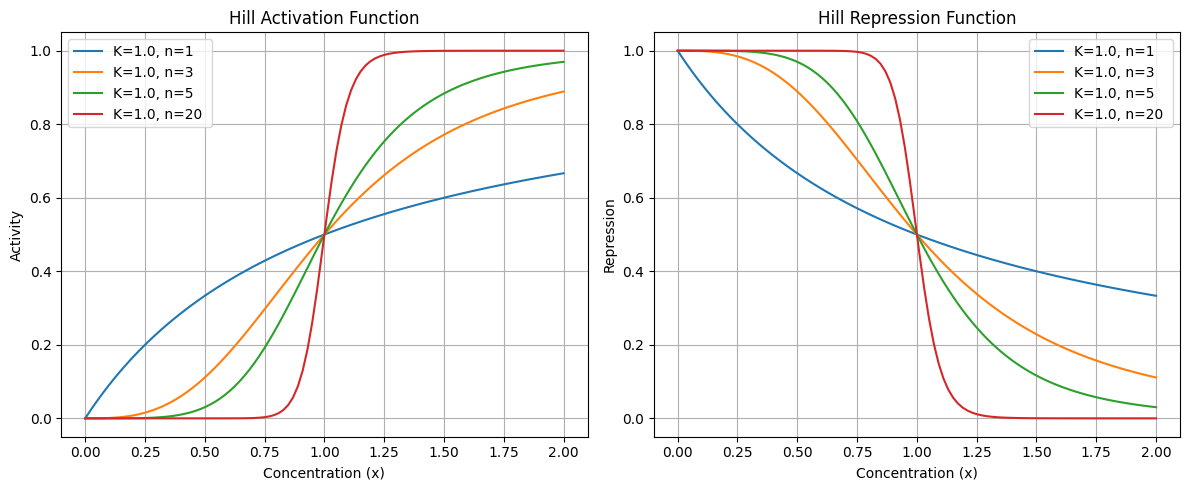

In [ ]:

# Generate a range of concentrations (x values)
x_vals = np.linspace(0, 2, 100)

# Plot Hill Activation for different K and n values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Hill Activation Function')
plt.plot(x_vals, hill_act(x_vals, K=1.0, n=1), label='K=1.0, n=1')
plt.plot(x_vals, hill_act(x_vals, K=1.0, n=3), label='K=1.0, n=3 ')
plt.plot(x_vals, hill_act(x_vals, K=1.0, n=5), label='K=1.0, n=5 ')
plt.plot(x_vals, hill_act(x_vals, K=1.0, n=20), label='K=1.0, n=20 ')
plt.xlabel('Concentration (x)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)

# Plot Hill Repression for different K and n values
plt.subplot(1, 2, 2)
plt.title('Hill Repression Function')
plt.plot(x_vals, hill_rep(x_vals, K=1.0, n=1), label='K=1.0, n=1')
plt.plot(x_vals, hill_rep(x_vals, K=1.0, n=3), label='K=1.0, n=3 ')
plt.plot(x_vals, hill_rep(x_vals, K=1.0, n=5), label='K=1.0, n=5 ')
plt.plot(x_vals, hill_rep(x_vals, K=1.0, n=20), label='K=1.0, n=20 ')
plt.xlabel('Concentration (x)')
plt.ylabel('Repression')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Simple Regulation**

This code snippet simulates a Simple Regulation Model using ordinary differential equations (ODEs) to describe how the concentration of a substance x changes over time.

**Parameters Initialization:**

beta = 1.0: Sets the constant production rate.
alpha = 1.0: Sets the removal parameter.
x0 = 0.0: Defines the initial concentration of x at t=0.
t = np.linspace(0, 25, 51): Creates an array of 51 evenly spaced time points from 0 to 25. The ODE will be solved over this time span.

**Solving the ODE:**

sol = odeint(pend, x0, t, args=(beta, alpha)): This line uses scipy.integrate.odeint to numerically solve the differential equation defined by the pend function.
pend: The function defining dxdt.
x0: The initial condition for x.
t: The time points at which to solve the ODE.
args=(beta, alpha): Passes beta and alpha as additional arguments to the pend function.
The result sol is a NumPy array where sol[:, 0] contains the concentration of x at each corresponding time point in t.

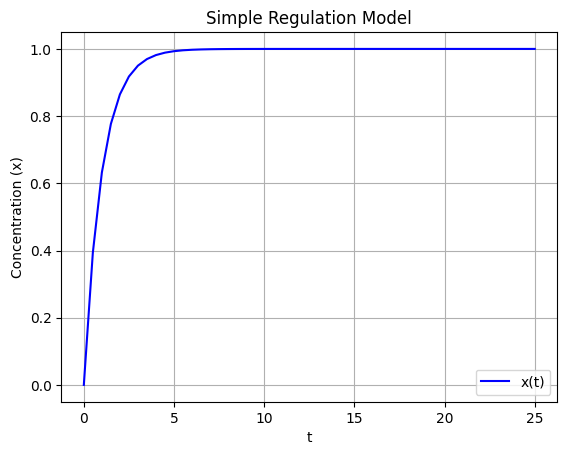

In [ ]:
def pend(x, t, beta, alpha):

    dxdt = beta-alpha*x
    return dxdt

beta = 1.0                 #production rate #repression case beta=0.0 and x0=1.0 st conc
alpha = 1.0                 #removal parameter
x0 = 0.0              #initial conditions
t = np.linspace(0, 25, 51)  #time

sol = odeint(pend,x0, t, args=(beta, alpha)) #extra arguments

plt.plot(t, sol[:, 0], 'b', label='x(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('Concentration (x)')
plt.title('Simple Regulation Model')
plt.grid()
plt.show()

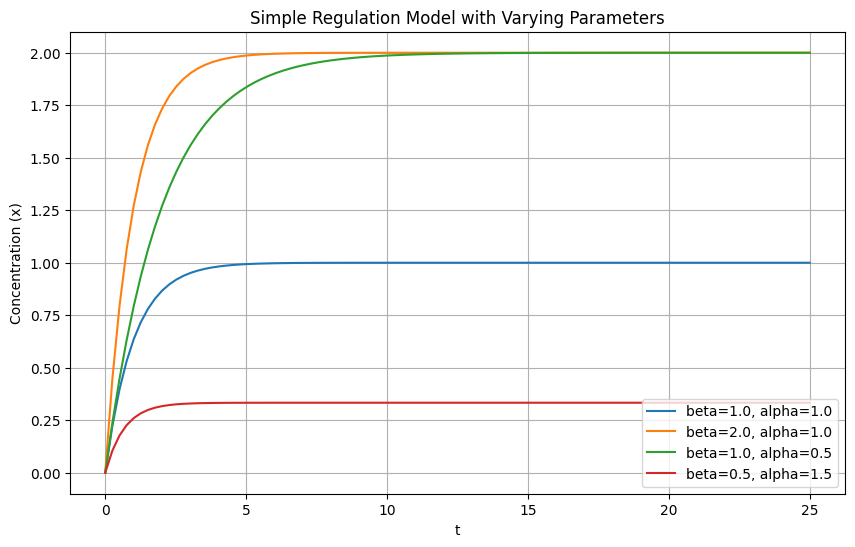

In [ ]:


# Define a set of parameters to test
params_to_test = [
    {'beta': 1.0, 'alpha': 1.0, 'label': 'beta=1.0, alpha=1.0'},
    {'beta': 2.0, 'alpha': 1.0, 'label': 'beta=2.0, alpha=1.0'},
    {'beta': 1.0, 'alpha': 0.5, 'label': 'beta=1.0, alpha=0.5'},
    {'beta': 0.5, 'alpha': 1.5, 'label': 'beta=0.5, alpha=1.5'}
]

x0 = 0.0  # initial conditions
t = np.linspace(0, 25, 100)  # time array

plt.figure(figsize=(10, 6))
plt.title('Simple Regulation Model with Varying Parameters')
plt.xlabel('t')
plt.ylabel('Concentration (x)')
plt.grid(True)

for params in params_to_test:
    beta_val = params['beta']
    alpha_val = params['alpha']
    label_val = params['label']

    # Solve ODE for current parameters
    sol = odeint(pend, x0, t, args=(beta_val, alpha_val))

    # Plot the solution
    plt.plot(t, sol[:, 0], label=label_val)

plt.legend(loc='best')
plt.show()

**Negative autoregulation (NAR)**

simulates a Negative Autoregulation (NAR) Model using ordinary differential equations (ODEs). It demonstrates how a substance x can repress its own production, a common feedback mechanism in biological systems.

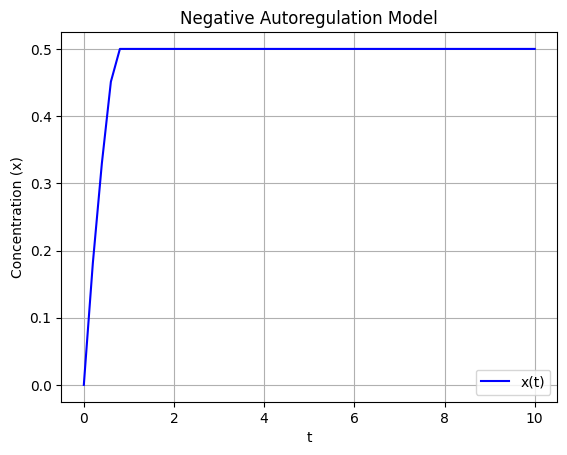

In [ ]:
def pend(x, t, beta, alpha):
    n = 1000  # Hill coefficient, chosen to be high for a switch-like response
    K = 0.5   # Dissociation constant (threshold)
    # The production term now includes hill_rep(x,K,n)
    dxdt = beta*hill_rep(x,K,n)-alpha*x
    return dxdt

beta = 1.0                 # production rate
alpha = 1.0                 # removal parameter
x0 = 0.0              # initial conditions
t = np.linspace(0, 10, 51)  # time

sol = odeint(pend,x0, t, args=(beta, alpha)) # solve the ODE

plt.plot(t, sol[:, 0], 'b', label='x(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('Concentration (x)')
plt.title('Negative Autoregulation Model')
plt.grid()
plt.show()

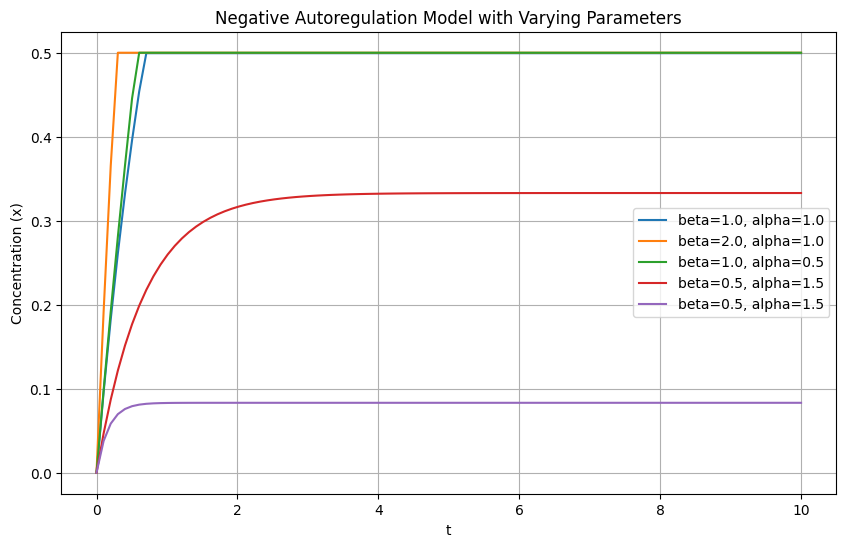

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

def hill_rep(x, K, n):
    return (K**n)/((K**n)+(x**n))

def pend(x, t, beta, alpha):
    n = 1000  # Hill coefficient
    K = 0.5   # Dissociation constant
    dxdt = beta * hill_rep(x, K, n) - alpha * x
    return dxdt

# Define a set of parameters to test
params_to_test = [
    {'beta': 1.0, 'alpha': 1.0, 'label': 'beta=1.0, alpha=1.0'},
    {'beta': 2.0, 'alpha': 1.0, 'label': 'beta=2.0, alpha=1.0'},
    {'beta': 1.0, 'alpha': 0.5, 'label': 'beta=1.0, alpha=0.5'},
    {'beta': 0.5, 'alpha': 1.5, 'label': 'beta=0.5, alpha=1.5'},
    {'beta': 0.5, 'alpha': 6.0, 'label': 'beta=0.5, alpha=6.0'}
]

x0 = 0.0  # initial conditions
t = np.linspace(0, 10, 100)  # time array

plt.figure(figsize=(10, 6))
plt.title('Negative Autoregulation Model with Varying Parameters')
plt.xlabel('t')
plt.ylabel('Concentration (x)')
plt.grid(True)

for params in params_to_test:
    beta_val = params['beta']
    alpha_val = params['alpha']
    label_val = params['label']

    # Solve ODE for current parameters
    sol = odeint(pend, x0, t, args=(beta_val, alpha_val))

    # Plot the solution
    plt.plot(t, sol[:, 0], label=label_val)

plt.legend(loc='best')
plt.show()

**Signal is ON till t=5; then OFF**

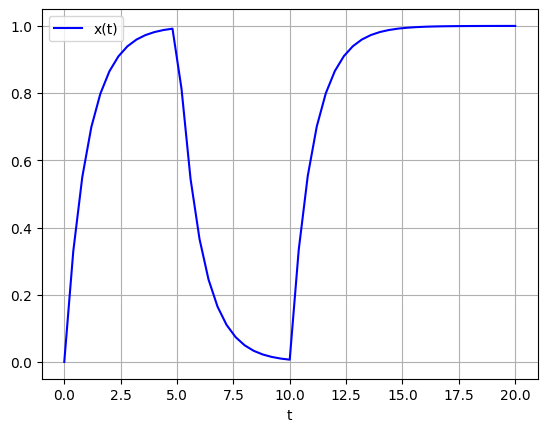

In [ ]:
def b_func(t, t_on1 = 5, t_on2 = 10):
    # b is 1 until t = 5, then 0
    if t <= t_on1 or t>t_on2:
        return 1
    else:
        return 0

def pend(x, t, alpha):
    beta = b_func(t) #production rate
    dxdt = beta-alpha*x
    return dxdt


alpha = 1.0                 #removal parameter
x0 = 0              #initial conditions
t = np.linspace(0, 20, 51)  #time

sol = odeint(pend,x0, t, args=(alpha,))

plt.plot(t, sol[:, 0], 'b', label='x(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

**Negative autoregulation (NAR)**

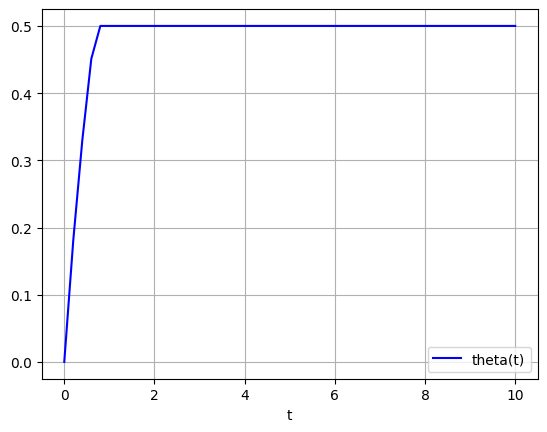

In [ ]:

def pend(x, t, beta, alpha):
    n = 1000
    K = 0.5
    dxdt = beta*hill_rep(x,K,n)-alpha*x
    return dxdt

beta = 1.0                 #production rate #repression case beta=0.0 and x0=1.0 st conc
alpha = 1.0                 #removal parameter
x0 = 0.0              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend,x0, t, args=(beta, alpha)) #extra arguments

plt.plot(t, sol[:, 0], 'b', label='theta(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

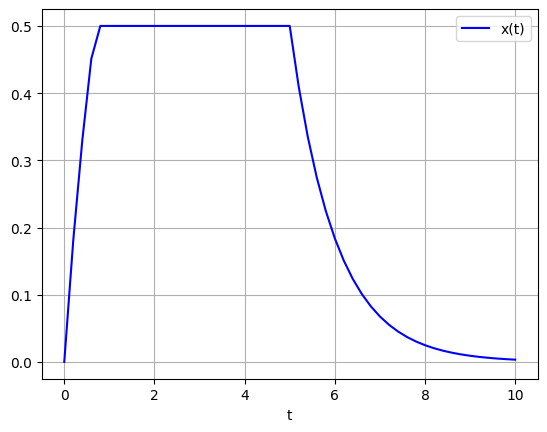

In [ ]:

def pend(x, t, alpha):
    n = 1000
    K = 0.5
    beta = b_func(t)
    dxdt = beta*hill_rep(x,K,n)-alpha*x
    return dxdt


alpha = 1.0                 #removal parameter
x0 = 0.0              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend,x0, t, args=(alpha,)) #extra arguments

plt.plot(t, sol[:, 0], 'b', label='x(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

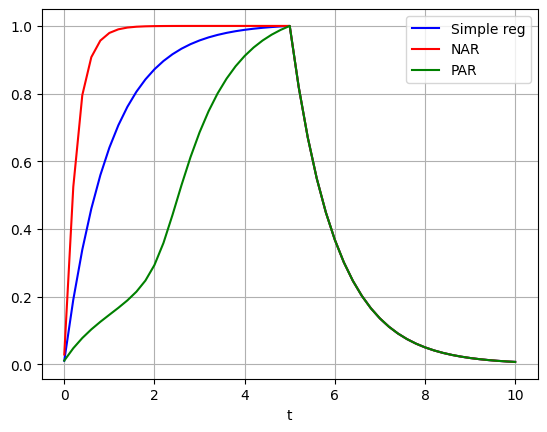

In [ ]:
def pend(x, t, alpha):
    xs,xn,xp = x
    n = 4
    K = 0.3
    eps = 0.2
    beta = b_func(t)
    dx_simple = beta-alpha*xs
    dx_nar = beta*hill_rep(xn,K,n)-alpha*xn
    dx_par = beta * (eps + (1 - eps)*hill_act(xp, K, n)) - alpha*xp
    ode_set = [dx_simple, dx_nar, dx_par]
    return ode_set


alpha = 1.0                 #removal parameter
x0 = [0.01, 0.01, 0.01]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend,x0, t, args=(alpha,)) #extra arguments

plt.plot(t, sol[:, 0]/max(sol[:, 0]), 'b', label='Simple reg')
plt.plot(t, sol[:, 1]/max(sol[:, 1]), 'r', label='NAR')
plt.plot(t, sol[:, 2]/max(sol[:, 2]), 'g', label='PAR')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

**I1-FFL Dynamic Modeling**

This code snippet simulates an I1-FFL (Incoherent Type 1 Feed-Forward Loop), a common network motif in biological systems. This type of circuit involves three components: X, Y, and Z, where X activates Y, X activates Z, and Y represses Z. The 'incoherent' part comes from X having both a direct activating effect on Z and an indirect repressive effect on Z (via Y).

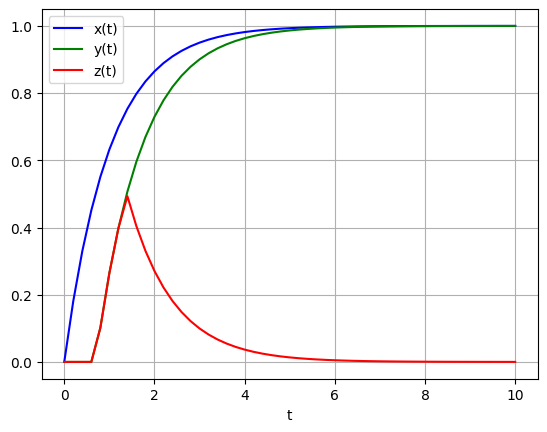

In [ ]:

def pend(y, t, beta, alpha):

    X, Y, Z = y
    n = 1000
    K = 0.5
    dxdt = beta-alpha*X
    dydt = beta*hill_act(X, K, n)-alpha*Y
    dzdt = beta*hill_act(X, K, n)*hill_rep(Y, K, n)-alpha*Z
    ode_set = [dxdt, dydt, dzdt]
    return ode_set


beta = 1.0                  #production rate
alpha = 1.0                 #removal parameter
y0 = [0, 0, 0]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend, y0, t, args=(beta, alpha))

plt.plot(t, sol[:, 0], 'b', label='x(t)')
plt.plot(t, sol[:, 1], 'g', label='y(t)')
plt.plot(t, sol[:, 2], 'r', label='z(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

In [ ]:
sol

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.81269237e-01, 0.00000000e+00, 0.00000000e+00],
       [3.29679943e-01, 0.00000000e+00, 0.00000000e+00],
       [4.51188353e-01, 0.00000000e+00, 0.00000000e+00],
       [5.50671022e-01, 1.01337769e-01, 1.01337769e-01],
       [6.32120562e-01, 2.64237624e-01, 2.64237624e-01],
       [6.98805787e-01, 3.97608707e-01, 3.97608707e-01],
       [7.53403033e-01, 5.06803718e-01, 4.93200860e-01],
       [7.98103485e-01, 5.96205049e-01, 4.03798702e-01],
       [8.34701127e-01, 6.69400680e-01, 3.30602390e-01],
       [8.64664718e-01, 7.29328148e-01, 2.70674365e-01],
       [8.89196842e-01, 7.78392629e-01, 2.21609429e-01],
       [9.09282044e-01, 8.18563224e-01, 1.81438461e-01],
       [9.25726423e-01, 8.51452138e-01, 1.48549241e-01],
       [9.39189940e-01, 8.78379301e-01, 1.21621828e-01],
       [9.50212934e-01, 9.00425395e-01, 9.95755299e-02],
       [9.59237799e-01, 9.18475210e-01, 8.15255475e-02],
       [9.66626735e-01, 9.33253

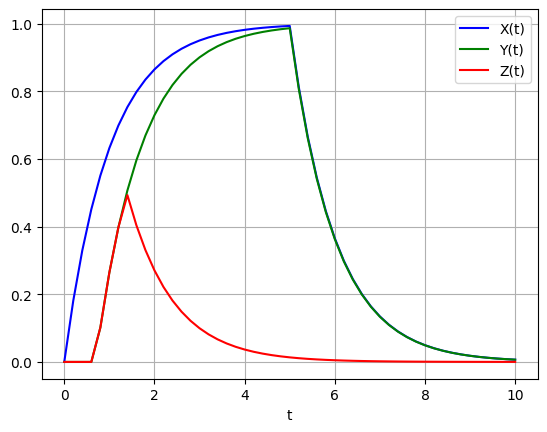

In [ ]:
def b_func(t, t_on1 = 5, t_on2 = 10):
    # b is 1 until t = 5, then 0
    if t <= t_on1 or t>t_on2:
        return 1
    else:
        return 0

def pend(y, t, alpha):

    X, Y, Z = y
    n = 1000
    K = 0.5
    beta = b_func(t) #production rate
    dxdt = beta-alpha*X
    dydt = beta*hill_act(X, K, n)-alpha*Y
    dzdt = beta*hill_act(X, K, n)*hill_rep(Y, K, n)-alpha*Z
    ode_set = [dxdt, dydt, dzdt]
    return ode_set



alpha = 1.0                 #removal parameter
y0 = [0, 0, 0]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend, y0, t, args=( alpha,))

plt.plot(t, sol[:, 0], 'b', label='X(t)')
plt.plot(t, sol[:, 1], 'g', label='Y(t)')
plt.plot(t, sol[:, 2], 'r', label='Z(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

**C1-FFL Dynamics**

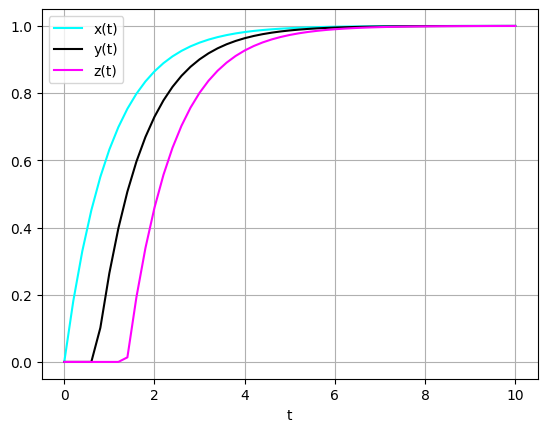

In [ ]:
import numpy as np

def hill_act(x, K, n):
    return (x**n)/((K**n)+(x**n))

def hill_rep(x, K, n):
    return (K**n)/((K**n)+(x**n))

def pend(init, t, b, a, K):
    x, y, z = init

    n = 1000


    dxdt = b - a*x
    dydt = b * hill_act(x, K, n) - a*y
    dzdt = b * hill_act(x, K, n) * hill_act(y, K, n) - a*z

    ode_set = [dxdt, dydt, dzdt]
    return ode_set

b = 1
a = 1
K = 0.5


init = [0, 0, 0]

t = np.linspace(0, 10, 51)

from scipy.integrate import odeint
sol = odeint(pend, init, t, args=(b, a, K))

import matplotlib.pyplot as plt
plt.plot(t, sol[:, 0], 'cyan', label='x(t)')
plt.plot(t, sol[:, 1], 'black', label='y(t)')
plt.plot(t, sol[:, 2], 'magenta', label='z(t)')

plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

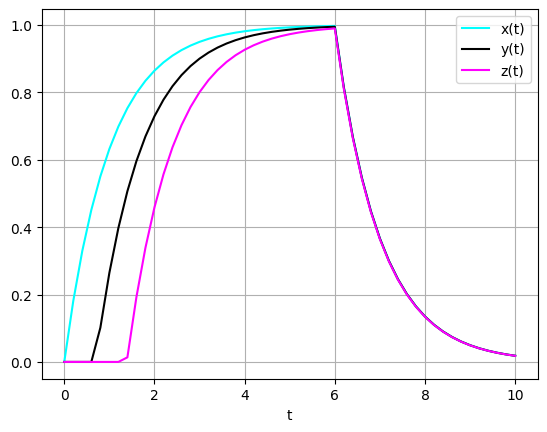

In [ ]:

def pend(init, t, a, K):
    x, y, z = init

    n = 1000
    b = b_func(t)

    dxdt = b - a*x
    dydt = b * hill_act(x, K, n) - a*y
    dzdt = b * hill_act(x, K, n) * hill_act(y, K, n) - a*z

    ode_set = [dxdt, dydt, dzdt]
    return ode_set

b = 1
a = 1
K = 0.5

"""
dxdt_values = [b - a * x for x in sol[:, 0]]
print(dxdt_values)
print(sol[:, 0])
"""

init = [0, 0, 0]

t = np.linspace(0, 10, 51)

from scipy.integrate import odeint
sol = odeint(pend, init, t, args=(a, K))

import matplotlib.pyplot as plt
plt.plot(t, sol[:, 0], 'cyan', label='x(t)')
plt.plot(t, sol[:, 1], 'black', label='y(t)')
plt.plot(t, sol[:, 2], 'magenta', label='z(t)')

plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

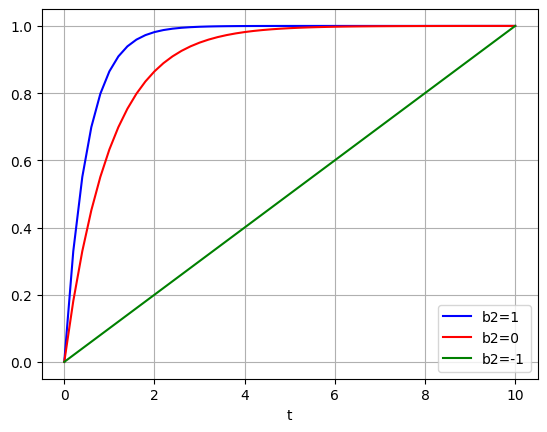

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

def pend(y, t, b1, b2, alpha):

    X = y

    dydt = b1-b2*X-alpha*X
    return dydt

b1 = 1.0
b2 = 1.0                  #production rate
alpha = 1.0                 #removal parameter
y0 = 0              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend, y0, t, args=(b1, b2, alpha))

plt.plot(t, sol[:, 0]/max(sol[:, 0]), 'b', label='b2=1')

sol = odeint(pend, y0, t, args=(b1, 0, alpha))

plt.plot(t, sol[:, 0]/max(sol[:, 0]), 'r', label='b2=0')

sol = odeint(pend, y0, t, args=(b1, -1, alpha))

plt.plot(t, sol[:, 0]/max(sol[:, 0]), 'g', label='b2=-1')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

**I1-FFL with Boolean Function**

X, Y, Z are the concentrations (or activities) of three components.

beta is the production rate, alpha is the removal/degradation rate.

K = 0.5 is a threshold that controls when production of Y and Z is turned on/off.

bool(...) converts a condition into 0 (False) or 1 (True), so it acts like an ON/OFF switch.

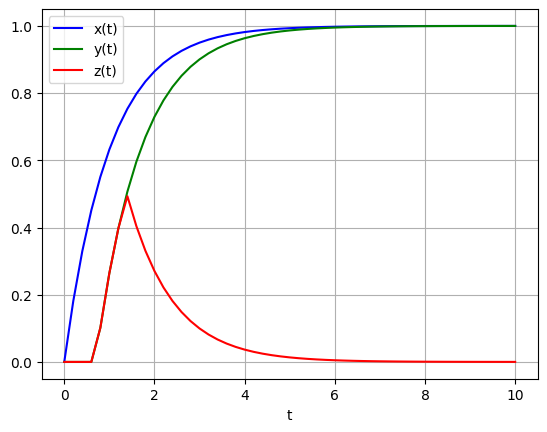

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

def pend(y, t, beta, alpha):

    X, Y, Z = y

    K = 0.5
    dxdt = beta-alpha*X
    dydt = beta*bool(X>K)-alpha*Y
    dzdt = beta*(bool(X>K) and bool(K>Y))-alpha*Z
    ode_set = [dxdt, dydt, dzdt]
    return ode_set


beta = 1.0                  #production rate
alpha = 1.0                 #removal parameter
y0 = [0, 0, 0]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend, y0, t, args=(beta, alpha))

plt.plot(t, sol[:, 0], 'b', label='x(t)')
plt.plot(t, sol[:, 1], 'g', label='y(t)')
plt.plot(t, sol[:, 2], 'r', label='z(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

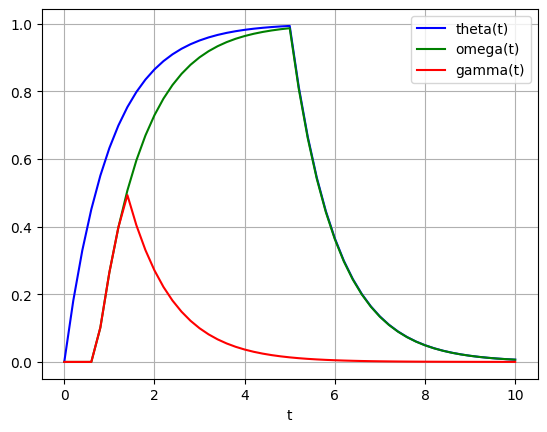

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

def pend(y, t, alpha):

    X, Y, Z = y
    beta = b_func(t)
    K = 0.5
    dxdt = beta-alpha*X
    dydt = beta*bool(X>K)-alpha*Y
    dzdt = beta*(bool(X>K) and bool(K>Y))-alpha*Z
    ode_set = [dxdt, dydt, dzdt]
    return ode_set


                  #production rate
alpha = 1.0                 #removal parameter
y0 = [0, 0, 0]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend, y0, t, args=(alpha, ))

plt.plot(t, sol[:, 0], 'b', label='theta(t)')
plt.plot(t, sol[:, 1], 'g', label='omega(t)')
plt.plot(t, sol[:, 2], 'r', label='gamma(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

**C1-FFL with Boolean Function**

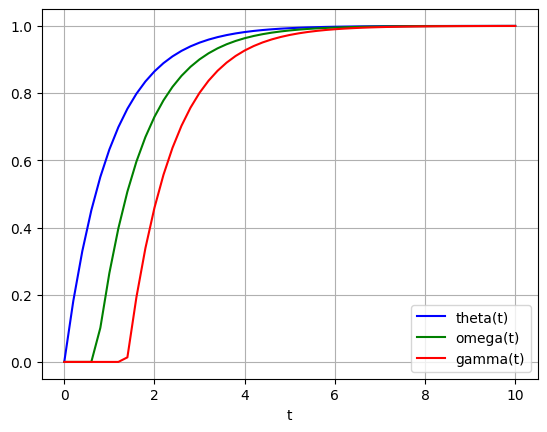

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

def pend(y, t, beta, alpha):

    X, Y, Z = y
    K = 0.5
    Kxz = 0.1
    Kyz = 0.5
    dxdt = beta-alpha*X
    dydt = beta*bool(X>K)-alpha*Y
    dzdt = beta*(bool(X>Kxz) and bool(Y>Kyz))-alpha*Z
    ode_set = [dxdt, dydt, dzdt]
    return ode_set


beta = 1.0                  #production rate
alpha = 1.0                 #removal parameter
y0 = [0, 0, 0]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend, y0, t, args=(beta, alpha))

plt.plot(t, sol[:, 0], 'b', label='theta(t)')
plt.plot(t, sol[:, 1], 'g', label='omega(t)')
plt.plot(t, sol[:, 2], 'r', label='gamma(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

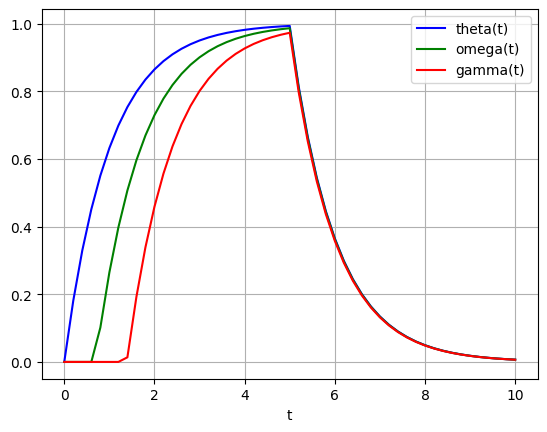

In [ ]:
def pend(y, t, alpha):

    X, Y, Z = y
    beta = b_func(t)
    K=0.5
    Kxz = 0.1
    Kyz = 0.5
    dxdt = beta-alpha*X
    dydt = beta*bool(X>K)-alpha*Y
    dzdt = beta*(bool(X>Kxz) and bool(Y>Kyz))-alpha*Z
    ode_set = [dxdt, dydt, dzdt]
    return ode_set

                  #production rate
alpha = 1.0                 #removal parameter
y0 = [0, 0, 0]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend, y0, t, args=(alpha,))

plt.plot(t, sol[:, 0], 'b', label='theta(t)')
plt.plot(t, sol[:, 1], 'g', label='omega(t)')
plt.plot(t, sol[:, 2], 'r', label='gamma(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

**Two-node FBL Oscillations**

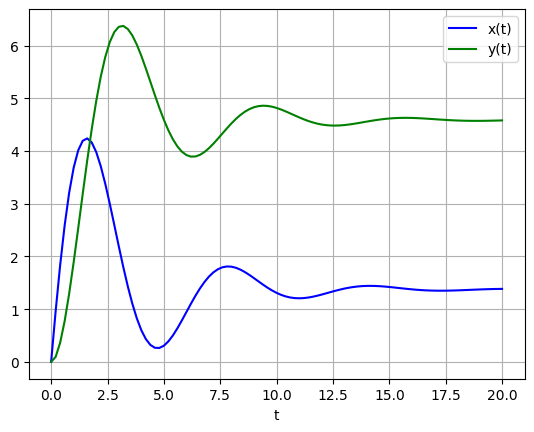

In [ ]:
import numpy as np

def pend(init, t, b, a):
    x, y = init
    b1, b2 = b
    a1, a2 = a

    dxdt = (5-b1*y)-a1*x
    dydt = (b2*x)-a2*y
    ode_set = [dxdt, dydt]
    return ode_set

b = [1, 1]
a = [0.3, 0.3]

init = [0, 0]

t = np.linspace(0, 20, 101)

from scipy.integrate import odeint
sol = odeint(pend, init, t, args=(b, a))

import matplotlib.pyplot as plt

plt.plot(t, sol[:, 0], 'b', label='x(t)')
plt.plot(t, sol[:, 1], 'g', label='y(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()


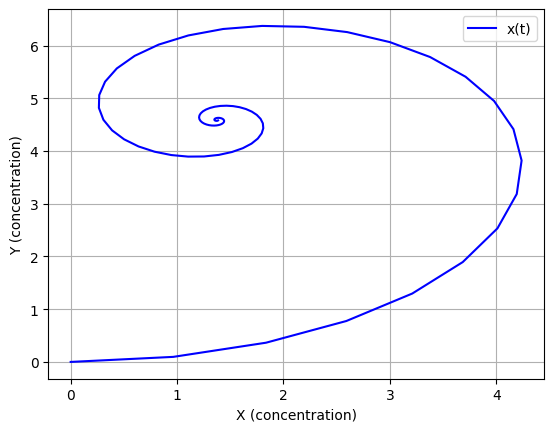

In [ ]:
plt.plot(sol[:, 0], sol[:, 1], 'b', label='x(t)')
plt.legend(loc='best')
plt.xlabel('X (concentration)')
plt.ylabel('Y (concentration)')
plt.grid()
plt.show()

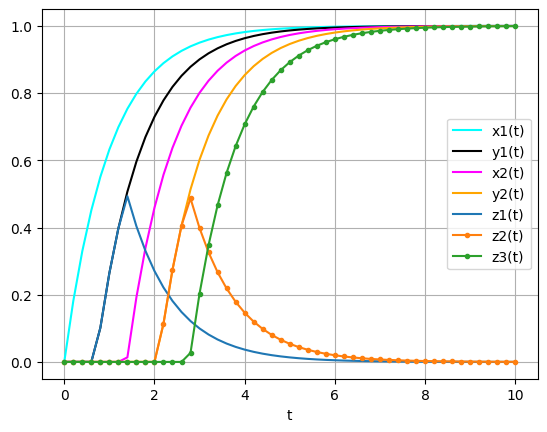

In [ ]:
import numpy as np

def hill_act(x, K, n):
    return (x**n)/((K**n)+(x**n))

def hill_rep(x, K, n):
    return (K**n)/((K**n)+(x**n))

def pend(init, t, b, a, K):
    x1, y1, z1, x2, y2, z2, z3 = init

    n = 1000


    dx1dt = b - a *x1
    dy1dt = b * hill_act(x1, K, n) - a*y1
    dz1dt = b * hill_act(x1, K, n) * hill_rep(y1, K, n) - a*z1
    dx2dt = b * hill_act(x1, K, n) * hill_act(y1, K, n)- a*x2
    dy2dt = b * hill_act(x2, K, n) - a*y2
    dz2dt = b * hill_act(x2, K, n) * hill_rep(y2, K, n) - a*z2
    dz3dt = b * hill_act(x2, K, n) * hill_act(y2, K, n) - a*z3

    ode_set = [dx1dt, dy1dt, dz1dt, dx2dt, dy2dt, dz2dt, dz3dt]
    return ode_set

b = 1
a = 1
K = 0.5

init = [0, 0, 0, 0, 0, 0, 0]

t = np.linspace(0, 10, 51)

from scipy.integrate import odeint
sol = odeint(pend, init, t, args=(b, a, K))

import matplotlib.pyplot as plt
plt.plot(t, sol[:, 0], 'cyan', label='x1(t)')
plt.plot(t, sol[:, 1], 'black', label='y1(t)')
plt.plot(t, sol[:, 3], 'magenta', label='x2(t)')
plt.plot(t, sol[:, 4], 'orange', label='y2(t)')
plt.plot(t, sol[:, 2], '-', label='z1(t)')
plt.plot(t, sol[:, 5], '.-', label='z2(t)')
plt.plot(t, sol[:, 6], '.-', label='z3(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

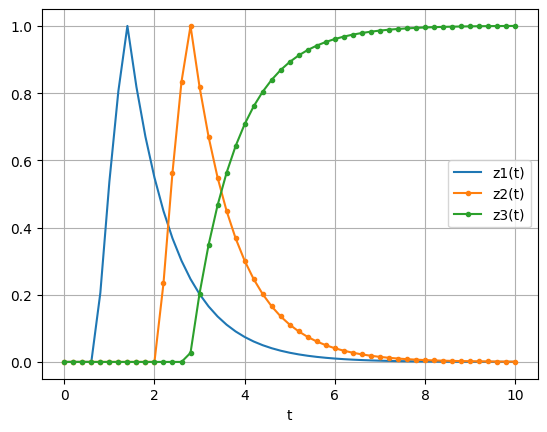

In [ ]:
import numpy as np

def hill_act(x, K, n):
    return (x**n)/((K**n)+(x**n))

def hill_rep(x, K, n):
    return (K**n)/((K**n)+(x**n))

def pend(init, t, b, a, K):
    x1, y1, z1, x2, y2, z2, z3 = init

    n = 1000


    dx1dt = b - a *x1
    dy1dt = b * hill_act(x1, K, n) - a*y1
    dz1dt = b * hill_act(x1, K, n) * hill_rep(y1, K, n) - a*z1
    dx2dt = b * hill_act(x1, K, n) * hill_act(y1, K, n)- a*x2
    dy2dt = b * hill_act(x2, K, n) - a*y2
    dz2dt = b * hill_act(x2, K, n) * hill_rep(y2, K, n) - a*z2
    dz3dt = b * hill_act(x2, K, n) * hill_act(y2, K, n) - a*z3

    ode_set = [dx1dt, dy1dt, dz1dt, dx2dt, dy2dt, dz2dt, dz3dt]
    return ode_set

b = 1
a = 1
K = 0.5

init = [0, 0, 0, 0, 0, 0, 0]

t = np.linspace(0, 10, 51)

from scipy.integrate import odeint
sol = odeint(pend, init, t, args=(b, a, K))

import matplotlib.pyplot as plt
#plt.plot(t, sol[:, 0], 'cyan', label='x1(t)')
#plt.plot(t, sol[:, 1], 'black', label='y1(t)')
#plt.plot(t, sol[:, 3], 'magenta', label='x2(t)')
#plt.plot(t, sol[:, 4], 'orange', label='y2(t)')
plt.plot(t, sol[:, 2]/max(sol[:, 2]), '-', label='z1(t)')
plt.plot(t, sol[:, 5]/max(sol[:, 5]), '.-', label='z2(t)')
plt.plot(t, sol[:, 6]/max(sol[:, 6]), '.-', label='z3(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

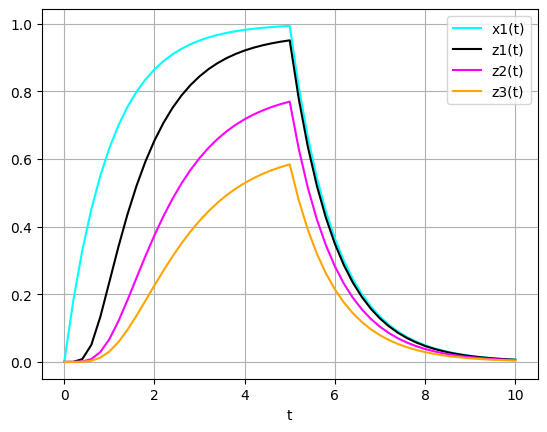

In [ ]:
def b_func(t):
    # b is 1 until t = 5, then 0
    if t <= 5:
        return 1
    else:
        return 0

def pend(init, t, a, K):
    x, z1, z2, z3 = init

    n = 5
    b = b_func(t)

    K1, K2, K3 = K
    dxdt = b - a *x
    dz1dt = b * hill_act(x, K1, n)  - a*z1
    dz2dt = b * hill_act(x, K2, n)  - a*z2
    dz3dt = b * hill_act(x, K3, n)  - a*z3

    ode_set = [dxdt, dz1dt, dz2dt, dz3dt]
    return ode_set

b = 1
a = 1
K = (0.5, 0.75, 0.9)

init = [0, 0, 0, 0]

t = np.linspace(0, 10, 51)

from scipy.integrate import odeint
sol = odeint(pend, init, t, args=(a, K))

import matplotlib.pyplot as plt
plt.plot(t, sol[:, 0], 'cyan', label='x1(t)')
plt.plot(t, sol[:, 1], 'black', label='z1(t)')
plt.plot(t, sol[:, 2], 'magenta', label='z2(t)')
plt.plot(t, sol[:, 3], 'orange', label='z3(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

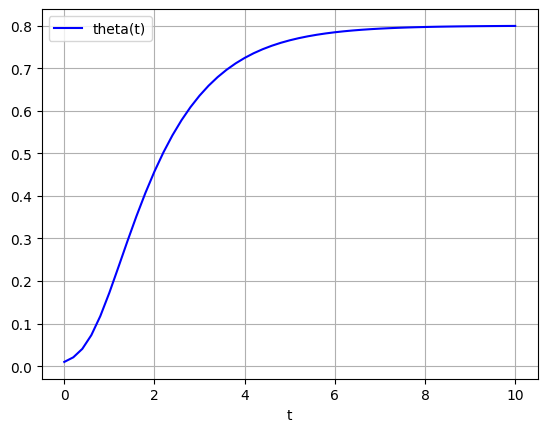

In [ ]:

def pend(x, t, alpha):
    n = 1
    K = 0.2
    beta = 1.0 #b_func(t)
    dxdt = beta*hill_act(x,K,n)-alpha*x
    return dxdt


alpha = 1.0                 #removal parameter
x0 = 0.01              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend,x0, t, args=(alpha,)) #extra arguments

plt.plot(t, sol[:, 0], 'b', label='theta(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

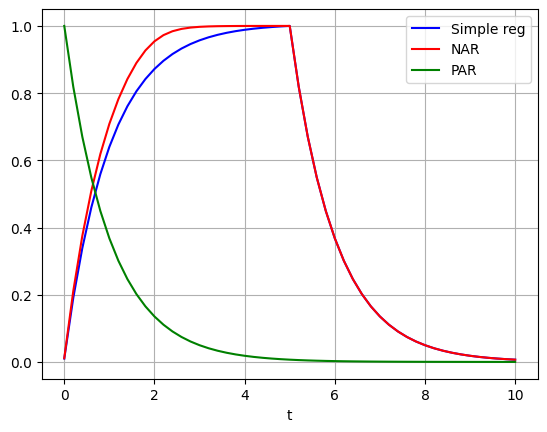

In [ ]:
def pend(x, t, alpha):
    xs,xn,xp = x
    n = 20
    K = 1
    beta = b_func(t)
    dx_simple = beta-alpha*xs
    dx_nar = beta*hill_rep(xn,K,n)-alpha*xn
    dx_par = beta*hill_act(xp,K,n)-alpha*xp
    ode_set = [dx_simple, dx_nar, dx_par]
    return ode_set


alpha = 1.0                 #removal parameter
x0 = [0.01, 0.01,0.01]              #initial conditions
t = np.linspace(0, 10, 51)  #time

sol = odeint(pend,x0, t, args=(alpha,)) #extra arguments

plt.plot(t, sol[:, 0]/max(sol[:, 0]), 'b', label='Simple reg')
plt.plot(t, sol[:, 1]/max(sol[:, 1]), 'r', label='NAR')
plt.plot(t, sol[:, 2]/max(sol[:, 2]), 'g', label='PAR')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()